In [1]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#plt.style.use('grayscale')

In [2]:
#lab_df = pd.read_csv('wf_labelled_data.csv')
lab_df = pd.read_csv('../Downloads/data-2022-08-01.csv')

In [3]:
labeler_root = 'GitHub/audio_labeller/www'
labeler_list = [l for l in os.listdir(labeler_root) if l not in ['tmp', 'JS']]
labeler_list

['davidfunosas',
 'hhussey3',
 'irishwildlifesounds',
 'markshorten',
 'mcauchoixxx']

In [4]:
lab_prefix = [v.split('@')[0] for v in lab_df.labeler]
lab_df['lab_folder'] = [l if l in labeler_list else 'tmp' for l in lab_prefix]

In [5]:
lab_df

,date_time,file_name,start_time,end_time,start_freq,end_freq,class_label,call_type,confidence,notes,labeler,id,lab_folder
0,22/05/2022 15:14,RICHFIELDM1_20220413_133400_start_0_14.wav,11.518955,12.280277,4.119626,6.176058,Eurasian Magpie,NaN,1.00,NaN,anthony.gibbons.2022@mumail.ie,1,tmp
1,22/05/2022 15:16,RICHFIELDM1_20220413_133400_start_0_14.wav,12.542371,14.189820,5.334790,9.307442,Eurasian Magpie,NaN,1.00,NaN,anthony.gibbons.2022@mumail.ie,2,tmp
2,22/05/2022 15:17,RICHFIELDM1_20220413_133400_start_0_14.wav,8.099250,9.322356,8.512912,10.195447,Eurasian Magpie,NaN,1.00,NaN,anthony.gibbons.2022@mumail.ie,3,tmp
3,22/05/2022 15:18,RICHFIELDM1_20220413_133400_start_0_14.wav,7.275526,8.698323,4.960893,7.484696,Eurasian Magpie,NaN,1.00,NaN,anthony.gibbons.2022@mumail.ie,5,tmp
4,22/05/2022 15:22,RICHFIELDM1_20220413_133400_start_0_14.wav,2.745040,3.755975,8.185752,10.943240,Eurasian Magpie,NaN,1.00,NaN,anthony.gibbons.2022@mumail.ie,6,tmp
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2154,15/08/2022 19:52,TEEVURCHER_20220530_190500_start_2_20.wav,1.822838,4.161781,0.631594,3.536837,Blackbird,NaN,0.95,NaN,markshorten@icloud.com,1,markshorten
2155,15/08/2022 19:53,TEEVURCHER_20220530_192000_start_3_16.wav,3.770404,6.547316,0.725312,8.035277,hooded crow,NaN,0.95,NaN,markshorten@icloud.com,1,markshorten
2156,15/08/2022 19:53,TEEVURCHER_20220530_192000_start_3_30.wav,9.883339,10.405175,-0.011719,10.940520,Anthropogenic Noise,NaN,0.95,NaN,markshorten@icloud.com,1,markshorten
2157,15/08/2022 19:53,TEEVURCHER_20220530_192000_start_3_30.wav,5.382504,5.690014,-0.011719,10.050203,Anthropogenic Noise,NaN,0.95,NaN,markshorten@icloud.com,1,markshorten


In [6]:
#lab_df[~lab_df.notes.isna()]

In [7]:
audio_paths = [os.path.join('wf_data_clips', r.file_name) for i,r in lab_df.iterrows()]
audio_paths_exists = [os.path.exists(p) for p in audio_paths]
#do they all exist
np.mean(audio_paths_exists)

0.9953682260305697

In [8]:
import tensorflow as tf

In [9]:
#commands = np.array(tf.io.gfile.listdir(str(data_dir)))
#commands = commands[commands != 'README.md']
#print('Commands:', commands)

In [10]:
#tf.convert_to_tensor

In [11]:
#filenames = tf.io.gfile.glob(str(data_dir) + '/*/*')
filenames = tf.convert_to_tensor(np.unique(np.array(audio_paths)))
filenames = tf.random.shuffle(filenames)
num_samples = len(filenames)
print('Number of total examples:', num_samples)
#print('Number of examples per label:',
#      len(tf.io.gfile.listdir(str(data_dir/commands[0]))))
print('Example file tensor:', filenames[0])

Number of total examples: 558
Example file tensor: tf.Tensor(b'wf_data_clips\\2_RICHFIELDMET_20211218_111120.wav', shape=(), dtype=string)


In [12]:
filenames = [f.numpy().decode().replace('\\', '/') for f in filenames]
#filenames = [f.replace('/', os.path.sep) for f in filenames]
filenames = [f for f in filenames if os.path.exists(f)]

In [13]:
os.path.exists(filenames[0])

True

In [14]:
len(filenames)

556

In [15]:
#get_waveform_and_label(filenames[0])

In [16]:
#train_files = filenames[:6400]
#val_files = filenames[6400: 6400 + 800]
#test_files = filenames[-800:]

#print('Training set size', len(train_files))
#print('Validation set size', len(val_files))
#print('Test set size', len(test_files))

In [17]:
#test_file = tf.io.read_file(DATASET_PATH+'/down/0a9f9af7_nohash_0.wav')
#test_audio, _ = tf.audio.decode_wav(contents=test_file)
#test_audio.shape

In [18]:
def decode_audio(audio_binary):
    # Decode WAV-encoded audio files to `float32` tensors, normalized
    # to the [-1.0, 1.0] range. Return `float32` audio and a sample rate.
    audio, sr = tf.audio.decode_wav(contents=audio_binary)
    # Since all the data is single channel (mono), drop the `channels`
    # axis from the array.
    return tf.squeeze(audio, axis=-1), sr

In [19]:
def get_label(file_path):
    parts = tf.strings.split(
      input=file_path,
      sep='/')#os.path.sep)
    # Note: You'll use indexing here instead of tuple unpacking to enable this
    # to work in a TensorFlow graph.
    return parts[-2]

In [20]:
def get_waveform_and_label(file_path):
    label = get_label(file_path)
    audio_binary = tf.io.read_file(file_path)
    waveform,sr = decode_audio(audio_binary)
    return waveform, sr,label

In [21]:
def plot_spectrogram(spectrogram, ax):
    if len(spectrogram.shape) > 2:
        assert len(spectrogram.shape) == 3
        spectrogram = np.squeeze(spectrogram, axis=-1)
    # Convert the frequencies to log scale and transpose, so that the time is
    # represented on the x-axis (columns).
    # Add an epsilon to avoid taking a log of zero.
    log_spec = np.log(spectrogram.T + np.finfo(float).eps)
    height = log_spec.shape[0]
    width = log_spec.shape[1]
    X = np.linspace(0, np.size(spectrogram), num=width, dtype=int)
    Y = range(height)
    ax.pcolormesh(X, Y, log_spec)

In [22]:
AUTOTUNE = tf.data.AUTOTUNE

files_ds = tf.data.Dataset.from_tensor_slices(filenames)

waveform_ds = files_ds.map(
    map_func=get_waveform_and_label,
    num_parallel_calls=AUTOTUNE)

In [35]:
for waveform, sr,label in waveform_ds.take(6):
    waveform = waveform
    label    = label
    sr = sr

In [36]:
waveform, sr

(<tf.Tensor: shape=(360000,), dtype=float32, numpy=
 array([0.04089355, 0.03411865, 0.02709961, ..., 0.00317383, 0.00195312,
        0.00115967], dtype=float32)>,
 <tf.Tensor: shape=(), dtype=int32, numpy=24000>)

In [37]:
def get_spectrogram(waveform):
    # Zero-padding for an audio waveform with less than 16,000 samples.
    input_len = len(waveform)
    waveform = waveform[:input_len]
    zero_padding = tf.zeros(
      [input_len] - tf.shape(waveform),
      dtype=tf.float32)
    # Cast the waveform tensors' dtype to float32.
    waveform = tf.cast(waveform, dtype=tf.float32)
    # Concatenate the waveform with `zero_padding`, which ensures all audio
    # clips are of the same length.
    equal_length = tf.concat([waveform, zero_padding], 0)
    # Convert the waveform to a spectrogram via a STFT.
    spectrogram = tf.signal.stft(
      equal_length, frame_length=255, frame_step=128)
    # Obtain the magnitude of the STFT.
    spectrogram = tf.abs(spectrogram)
    # Add a `channels` dimension, so that the spectrogram can be used
    # as image-like input data with convolution layers (which expect
    # shape (`batch_size`, `height`, `width`, `channels`).
    spectrogram = spectrogram[..., tf.newaxis]
    return spectrogram

In [38]:
spectrogram = get_spectrogram(waveform)

In [39]:
spectrogram

<tf.Tensor: shape=(2811, 129, 1), dtype=float32, numpy=
array([[[9.9882793e-01],
        [1.5016935e+00],
        [1.2448368e+00],
        ...,
        [1.9787417e-03],
        [7.6636684e-04],
        [5.4255128e-04]],

       [[1.8396573e+00],
        [6.9689763e-01],
        [1.3745431e+00],
        ...,
        [1.6725831e-03],
        [2.5845026e-03],
        [1.1680126e-03]],

       [[7.5545686e-01],
        [1.3600554e+00],
        [9.3837059e-01],
        ...,
        [2.0893565e-03],
        [2.6199759e-03],
        [1.0903478e-03]],

       ...,

       [[7.7759230e-01],
        [3.3915472e+00],
        [2.9616075e+00],
        ...,
        [2.9775461e-03],
        [1.3237901e-03],
        [2.7677417e-04]],

       [[1.1955297e-01],
        [1.9133996e+00],
        [7.5374627e-01],
        ...,
        [2.0781038e-03],
        [1.1409431e-03],
        [9.4548240e-04]],

       [[5.5297655e-01],
        [1.1079165e+00],
        [2.2001629e+00],
        ...,
        [2.5965032

In [46]:
lab_df.class_label.unique()

array(['Eurasian Magpie', 'Common Kestrel', 'Wren', 'Noise', 'Rook',
       'Blackbird', 'Human', 'Woodpigeon', 'Chaffinch', 'Coal TIt',
       'Anthropogenic Noise', 'Dunnock', 'Great Tit', 'Linnet',
       'Meadow Pipit', 'Robin', 'Pied Wagtail', 'wren', 'blackbird',
       'chaffinch', 'linnet', 'rook', 'pied wagtail', 'meadow pipit',
       'blue tit', 'European Robin', 'mallard', 'sedge warbler',
       'Other Noise', 'stonechat', 'goldfinch', 'Geophonic Noise',
       'Mallard', 'song thrush', 'Bird - Cannot Identify',
       'Sedge Warbler', 'Curlew', 'Skylark', 'oystercatcher', 'swallow',
       'Grasshopper Warbler', 'Hooded Crow', 'Yellowhammer',
       'House Sparrow', 'Arctic Tern', 'Barn Swallow', 'Stonechat',
       'Goldfinch', 'robin', 'dunnock', 'Coal Tit', 'Teal', 'goldcrest',
       'great tit', 'Blue Tit', 'hooded crow', 'Insect Noise', 'Starling',
       'Pheasant', 'Magpie', 'Buzzard', 'Weather Noise', 'jackdaw'],
      dtype=object)

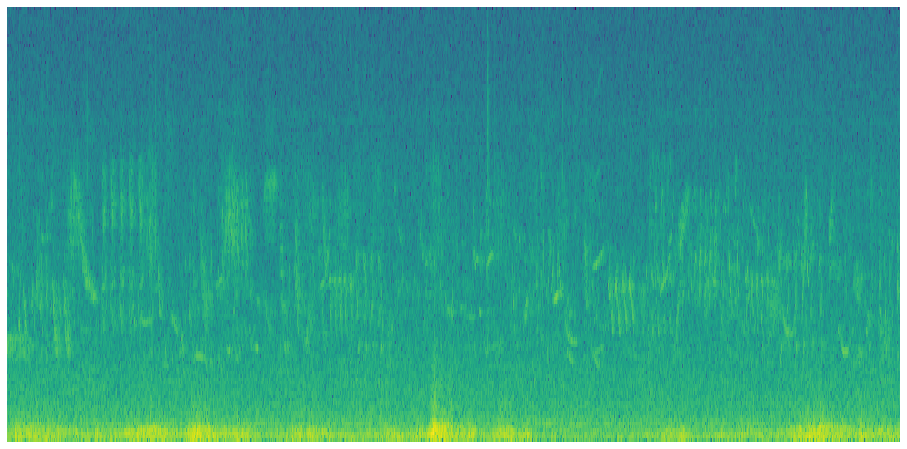

In [45]:
fig = plt.figure(figsize=(16, 8))
timescale = np.arange(waveform.shape[0])
#axes[0].plot(timescale, waveform.numpy())
#axes[0].set_title('Waveform')
#axes[0].set_xlim([0, len(waveform)])

plot_spectrogram(tf.math.pow(spectrogram, 1).numpy(), plt)
plt.axis('off')
plt.margins(x=0,y=0)
#axes[1].set_title('Spectrogram')
plt.show()

In [41]:
cmap='gray'

In [42]:
from PIL import Image
def spec_imsave(I, filepath):
    #I8 = (((I - I.min()) / (I.max() - I.min())) * 255.9).astype(np.uint8)

    #img = Image.fromarray(I8)
    #img.save(filepath)
    #fig = plt.figure(figsize=(16, 8))
    #timescale = np.arange(waveform.shape[0])
    #axes[0].plot(timescale, waveform.numpy())
    #axes[0].set_title('Waveform')
    #axes[0].set_xlim([0, len(waveform)])
    plt.figure()
    plot_spectrogram(I, plt)
    plt.axis('off')
    plt.margins(x=0,y=0)
    #axes[1].set_title('Spectrogram')
    plt.savefig(filepath, bbox_inches='tight', pad_inches = 0)
    plt.close()

In [43]:
#fn.numpy().decode().split(os.path.sep)[-1][:-3]+'png'

In [44]:
for fn in files_ds:
    #print(fn.numpy().decode())
    sav_name = fn.numpy().decode().split('/')[-1][:-3]+'png'
    #print(sav_name)
    wf, sr, lab = get_waveform_and_label(fn)
    spec = get_spectrogram(wf)
    spec_imsave(spec.numpy()[:,:,0], os.path.join('spec_images', sav_name))
    #print(wf)

In [52]:
len(files_ds)
lab_df.columns

Index(['date_time', 'file_name', 'start_time', 'end_time', 'start_freq',
       'end_freq', 'class_label', 'call_type', 'confidence', 'notes',
       'labeler', 'id', 'lab_folder'],
      dtype='object')

In [46]:
lab_df['class_label'] = [s.capitalize() for s in lab_df['class_label']]

In [47]:
labs_cnts = lab_df.groupby('class_label')[['class_label']].count()
labs_cnts[labs_cnts['class_label'] > 20].index

Index(['Anthropogenic noise', 'Bird - cannot identify', 'Blackbird',
       'Chaffinch', 'Dunnock', 'Hooded crow', 'Linnet', 'Meadow pipit',
       'Noise', 'Robin', 'Rook', 'Starling', 'Stonechat', 'Wren',
       'Yellowhammer'],
      dtype='object', name='class_label')

In [53]:
#lab_df['lab_folder'].isin(['anthony.gibbons.2022', 'tmp'])#.sum()
lab_df

,date_time,file_name,start_time,end_time,start_freq,end_freq,class_label,call_type,confidence,notes,labeler,id,lab_folder
0,22/05/2022 15:14,RICHFIELDM1_20220413_133400_start_0_14.wav,11.518955,12.280277,4.119626,6.176058,Eurasian magpie,NaN,1.00,NaN,anthony.gibbons.2022@mumail.ie,1,tmp
1,22/05/2022 15:16,RICHFIELDM1_20220413_133400_start_0_14.wav,12.542371,14.189820,5.334790,9.307442,Eurasian magpie,NaN,1.00,NaN,anthony.gibbons.2022@mumail.ie,2,tmp
2,22/05/2022 15:17,RICHFIELDM1_20220413_133400_start_0_14.wav,8.099250,9.322356,8.512912,10.195447,Eurasian magpie,NaN,1.00,NaN,anthony.gibbons.2022@mumail.ie,3,tmp
3,22/05/2022 15:18,RICHFIELDM1_20220413_133400_start_0_14.wav,7.275526,8.698323,4.960893,7.484696,Eurasian magpie,NaN,1.00,NaN,anthony.gibbons.2022@mumail.ie,5,tmp
4,22/05/2022 15:22,RICHFIELDM1_20220413_133400_start_0_14.wav,2.745040,3.755975,8.185752,10.943240,Eurasian magpie,NaN,1.00,NaN,anthony.gibbons.2022@mumail.ie,6,tmp
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2154,15/08/2022 19:52,TEEVURCHER_20220530_190500_start_2_20.wav,1.822838,4.161781,0.631594,3.536837,Blackbird,NaN,0.95,NaN,markshorten@icloud.com,1,markshorten
2155,15/08/2022 19:53,TEEVURCHER_20220530_192000_start_3_16.wav,3.770404,6.547316,0.725312,8.035277,Hooded crow,NaN,0.95,NaN,markshorten@icloud.com,1,markshorten
2156,15/08/2022 19:53,TEEVURCHER_20220530_192000_start_3_30.wav,9.883339,10.405175,-0.011719,10.940520,Anthropogenic noise,NaN,0.95,NaN,markshorten@icloud.com,1,markshorten
2157,15/08/2022 19:53,TEEVURCHER_20220530_192000_start_3_30.wav,5.382504,5.690014,-0.011719,10.050203,Anthropogenic noise,NaN,0.95,NaN,markshorten@icloud.com,1,markshorten


In [49]:
lab_df_sub = lab_df[(lab_df['class_label'].isin(labs_cnts[labs_cnts['class_label'] > 20].index))
                   & ~(lab_df['lab_folder'].isin(['anthony.gibbons.2022', 'tmp']))]

In [50]:
lab_df_sub

,date_time,file_name,start_time,end_time,start_freq,end_freq,class_label,call_type,confidence,notes,labeler,id,lab_folder
119,08/06/2022 22:03,RICHFIELDM1_20220413_133400_start_4_26.wav,1.240375,4.780796,1.014479,4.651003,Blackbird,NaN,1.00,NaN,hhussey3@gmail.com,1,hhussey3
120,08/06/2022 22:04,RICHFIELDM1_20220413_133400_start_4_26.wav,2.917417,4.664335,4.887141,9.090396,Wren,NaN,1.00,NaN,hhussey3@gmail.com,1,hhussey3
121,08/06/2022 22:05,RICHFIELDM1_20220413_133400_start_4_26.wav,6.748991,10.056490,0.353292,3.517541,Rook,NaN,1.00,NaN,hhussey3@gmail.com,1,hhussey3
122,08/06/2022 22:06,RICHFIELDM1_20220413_134900_start_1_24.wav,7.203190,12.164438,3.564768,8.995941,Wren,NaN,1.00,NaN,hhussey3@gmail.com,1,hhussey3
123,08/06/2022 22:06,RICHFIELDM1_20220413_134900_start_1_24.wav,7.366236,12.176084,0.967251,3.234175,Blackbird,NaN,1.00,NaN,hhussey3@gmail.com,1,hhussey3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2154,15/08/2022 19:52,TEEVURCHER_20220530_190500_start_2_20.wav,1.822838,4.161781,0.631594,3.536837,Blackbird,NaN,0.95,NaN,markshorten@icloud.com,1,markshorten
2155,15/08/2022 19:53,TEEVURCHER_20220530_192000_start_3_16.wav,3.770404,6.547316,0.725312,8.035277,Hooded crow,NaN,0.95,NaN,markshorten@icloud.com,1,markshorten
2156,15/08/2022 19:53,TEEVURCHER_20220530_192000_start_3_30.wav,9.883339,10.405175,-0.011719,10.940520,Anthropogenic noise,NaN,0.95,NaN,markshorten@icloud.com,1,markshorten
2157,15/08/2022 19:53,TEEVURCHER_20220530_192000_start_3_30.wav,5.382504,5.690014,-0.011719,10.050203,Anthropogenic noise,NaN,0.95,NaN,markshorten@icloud.com,1,markshorten


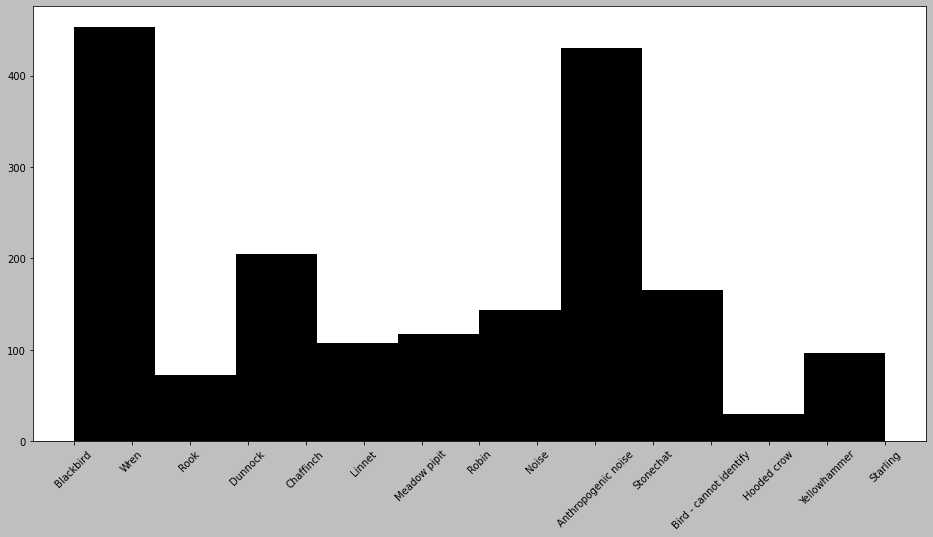

In [51]:
fig = plt.figure(figsize=(16, 8))
plt.hist(lab_df_sub['class_label'])
plt.xticks(rotation=45)
plt.show()